In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import os
import random
import time
import copy
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:

data_dir = '/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/REMP A Unique Dataset of Rare and Endangered Medicinal Plants in Bangladesh/Raw-Images/Raw-Images'

# Class names (16 classes)
class_names = [
    'Kalochitra',    # type_1
    'Anantamu',      # type_2
    'Apang',         # type_3
    'Syspan',        # type_4
    'Appishikha',    # type_5
    'Kalamegh',      # type_6
    'Kalothutura',   # type_7
    'Gshnru',        # type_8
    'Chapalish',     # type_9
    'Beta',          # type_10
    'Punarnava',     # type_11
    'Bamonhati',     # type_12
    'Basok',         # type_13
    'Ramtulsi',      # type_14
    'Shotomuli',     # type_15
    'Sarpagandha'    # type_16
]

num_classes = len(class_names)
print(f'Number of classes: {num_classes}')

# Verify folders and count images
print("\nVerifying dataset structure...")
total_images = 0
for i in range(1, 17):
    folder_path = os.path.join(data_dir, f'type_{i}')
    if os.path.exists(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        total_images += num_images
        print(f'type_{i} ({class_names[i-1]}): {num_images} images ✓')
    else:
        print(f'type_{i}: NOT FOUND ❌')

print(f'\nTotal images: {total_images}')

Number of classes: 16

Verifying dataset structure...
type_1 (Kalochitra): 201 images ✓
type_2 (Anantamu): 158 images ✓
type_3 (Apang): 280 images ✓
type_4 (Syspan): 294 images ✓
type_5 (Appishikha): 138 images ✓
type_6 (Kalamegh): 294 images ✓
type_7 (Kalothutura): 276 images ✓
type_8 (Gshnru): 238 images ✓
type_9 (Chapalish): 238 images ✓
type_10 (Beta): 194 images ✓
type_11 (Punarnava): 407 images ✓
type_12 (Bamonhati): 134 images ✓
type_13 (Basok): 151 images ✓
type_14 (Ramtulsi): 154 images ✓
type_15 (Shotomuli): 108 images ✓
type_16 (Sarpagandha): 229 images ✓

Total images: 3494


In [3]:

IMG_SIZE = 224

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
}


normalize_transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

In [4]:
from torch.utils.data import Dataset
import glob

class MedicinalPlantDataset(Dataset):
    def __init__(self, data_dir, class_names, transform=None, normalize=None):
        self.data = []
        self.labels = []
        self.transform = transform
        self.normalize = normalize
        
       
        for idx, class_name in enumerate(class_names):
            class_path = os.path.join(data_dir, f'type_{idx+1}')
            if os.path.exists(class_path):
                images = glob.glob(os.path.join(class_path, '*.*'))
                self.data.extend(images)
                self.labels.extend([idx] * len(images))
        
        print(f'Loaded {len(self.data)} images')
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]

        
        image = Image.open(img_path).convert('RGB')
        
        
        if self.transform:
            image = self.transform(image)
        
        # Apply normalization separately
        if self.normalize:
            image = self.normalize(image)
        
        return image, label

In [5]:
from sklearn.model_selection import train_test_split

# Load full dataset (without normalization first to split)
full_dataset = MedicinalPlantDataset(
    data_dir=data_dir,
    class_names=class_names,
    transform=transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor()
    ]),
    normalize=None
)

indices = list(range(len(full_dataset)))
labels = [full_dataset.labels[i] for i in indices]

# Split: 70% train, 15% val, 15% test (with stratify and fixed seed)
train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, random_state=SEED, stratify=labels
)

temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f'Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')

# Create subset datasets with normalization
from torch.utils.data import Subset

# Train dataset (with augmentation + normalization)
train_dataset = Subset(
    MedicinalPlantDataset(data_dir, class_names, 
                         transform=data_transforms['train'],
                         normalize=normalize_transform),
    train_idx
)

# Val dataset (with normalization)
val_dataset = Subset(
    MedicinalPlantDataset(data_dir, class_names,
                         transform=data_transforms['val'],
                         normalize=normalize_transform),
    val_idx
)

# Test dataset (with normalization)
test_dataset = Subset(
    MedicinalPlantDataset(data_dir, class_names,
                         transform=data_transforms['test'],
                         normalize=normalize_transform),
    test_idx
)

Loaded 3494 images
Train: 2445, Val: 524, Test: 525
Loaded 3494 images
Loaded 3494 images
Loaded 3494 images


In [6]:
BATCH_SIZE = 32

# DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,  # ONLY shuffle for training
    num_workers=2,
    worker_init_fn=lambda worker_id: np.random.seed(SEED + worker_id)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # No shuffle for validation
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # No shuffle for test
    num_workers=2
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 77
Val batches: 17
Test batches: 17


In [7]:
# Load EfficientNetB0 WITHOUT pretrained weights (train from scratch)
USE_PRETRAINED = False

model = models.efficientnet_b0(weights=None)

# Change the output layer (classifier) for 16 classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, num_classes)

# Move model to device
model = model.to(device)

print(f'EfficientNetB0 loaded with pretrained={USE_PRETRAINED}')
print(f'Output layer changed to {num_classes} classes')
print(model.classifier)

EfficientNetB0 loaded with pretrained=False
Output layer changed to 16 classes
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=16, bias=True)
)


In [8]:
# Loss: CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 
                scheduler, num_epochs=100, patience=10):
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    counter = 0  # Early stopping counter
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 50)
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in tqdm(train_loader, desc='Training'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc.item())
        
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='Validation'):
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
        
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        
        val_losses.append(val_loss)
        val_accs.append(val_acc.item())
        
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        # Learning rate scheduler
        scheduler.step(val_acc)
        
        # Early stopping check (based on validation accuracy)
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0  # Reset counter
            print(f'>>> Best model updated! Val Acc: {best_acc:.4f}')
        else:
            counter += 1
            print(f'Early stopping counter: {counter}/{patience}')
        
        # Stop if patience exceeded
        if counter >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            break
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f'\nBest Val Acc: {best_acc:.4f}')
    
    return model, train_losses, val_losses, train_accs, val_accs

In [10]:

NUM_EPOCHS = 100
PATIENCE = 10

start_time = time.time()

model, train_losses, val_losses, train_accs, val_accs = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE
)

training_time = time.time() - start_time
print(f'\nTotal Training Time: {training_time/60:.2f} minutes')


Epoch 1/100
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:16<00:00,  4.58it/s]


Train Loss: 2.1544 Acc: 0.2957


Validation: 100%|██████████| 17/17 [00:02<00:00,  5.74it/s]


Val Loss: 2.0065 Acc: 0.3359
>>> Best model updated! Val Acc: 0.3359

Epoch 2/100
--------------------------------------------------


...

Val Loss: 0.0243 Acc: 0.9943
Early stopping counter: 9/10

Epoch 48/100
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:14<00:00,  5.48it/s]


Train Loss: 0.0139 Acc: 0.9971


Validation: 100%|██████████| 17/17 [00:01<00:00,  9.25it/s]

Val Loss: 0.0312 Acc: 0.9905
Early stopping counter: 10/10

Early stopping triggered after 48 epochs

Best Val Acc: 0.9962

Total Training Time: 12.54 minutes


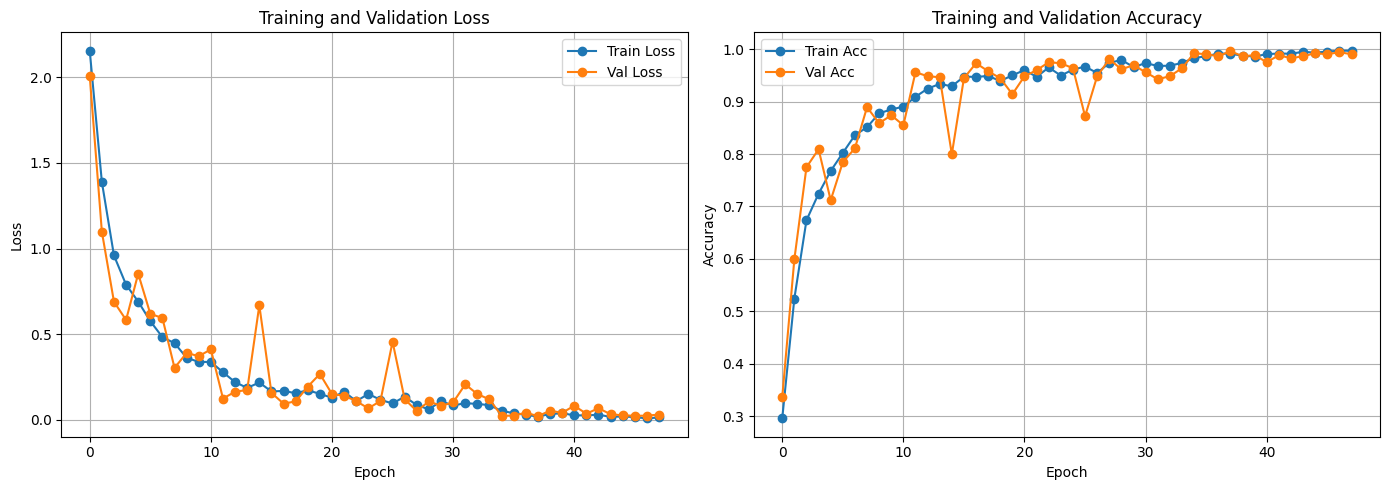

In [19]:
# Plot loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accs, label='Train Acc', marker='o')
ax2.plot(val_accs, label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [21]:
def evaluate_model(model, dataloader, criterion):
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0.0
    
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Get probabilities
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            total_loss += loss.item() * inputs.size(0)
    
    test_time = time.time() - start_time
    
    avg_loss = total_loss / len(dataloader.dataset)
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs), avg_loss, test_time

In [22]:
# Evaluate on test set
test_preds, test_labels, test_probs, test_loss, test_time = evaluate_model(
    model, test_loader, criterion
)

print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Time: {test_time:.2f} seconds')

# Calculate metrics
test_acc = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
test_recall = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
test_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)

print(f'\n=== Test Set Metrics ===')
print(f'Accuracy: {test_acc:.4f}')
print(f'Precision: {test_precision:.4f}')
print(f'Recall: {test_recall:.4f}')
print(f'F1-Score: {test_f1:.4f}')

# Per-class accuracy
print(f'\n=== Per-Class Accuracy ===')
cm = confusion_matrix(test_labels, test_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(class_names):
    print(f'{class_name}: {class_acc[i]:.4f}')

Evaluating: 100%|██████████| 17/17 [00:02<00:00,  8.00it/s]


Test Loss: 0.0485
Test Time: 2.13 seconds

=== Test Set Metrics ===
Accuracy: 0.9867
Precision: 0.9872
Recall: 0.9867
F1-Score: 0.9867

=== Per-Class Accuracy ===
Kalochitra: 1.0000
Anantamu: 1.0000
Apang: 0.9762
Syspan: 1.0000
Appishikha: 0.9524
Kalamegh: 1.0000
Kalothutura: 1.0000
Gshnru: 0.9722
Chapalish: 1.0000
Beta: 0.9655
Punarnava: 0.9836
Bamonhati: 1.0000
Basok: 0.9545
Ramtulsi: 1.0000
Shotomuli: 1.0000
Sarpagandha: 0.9714


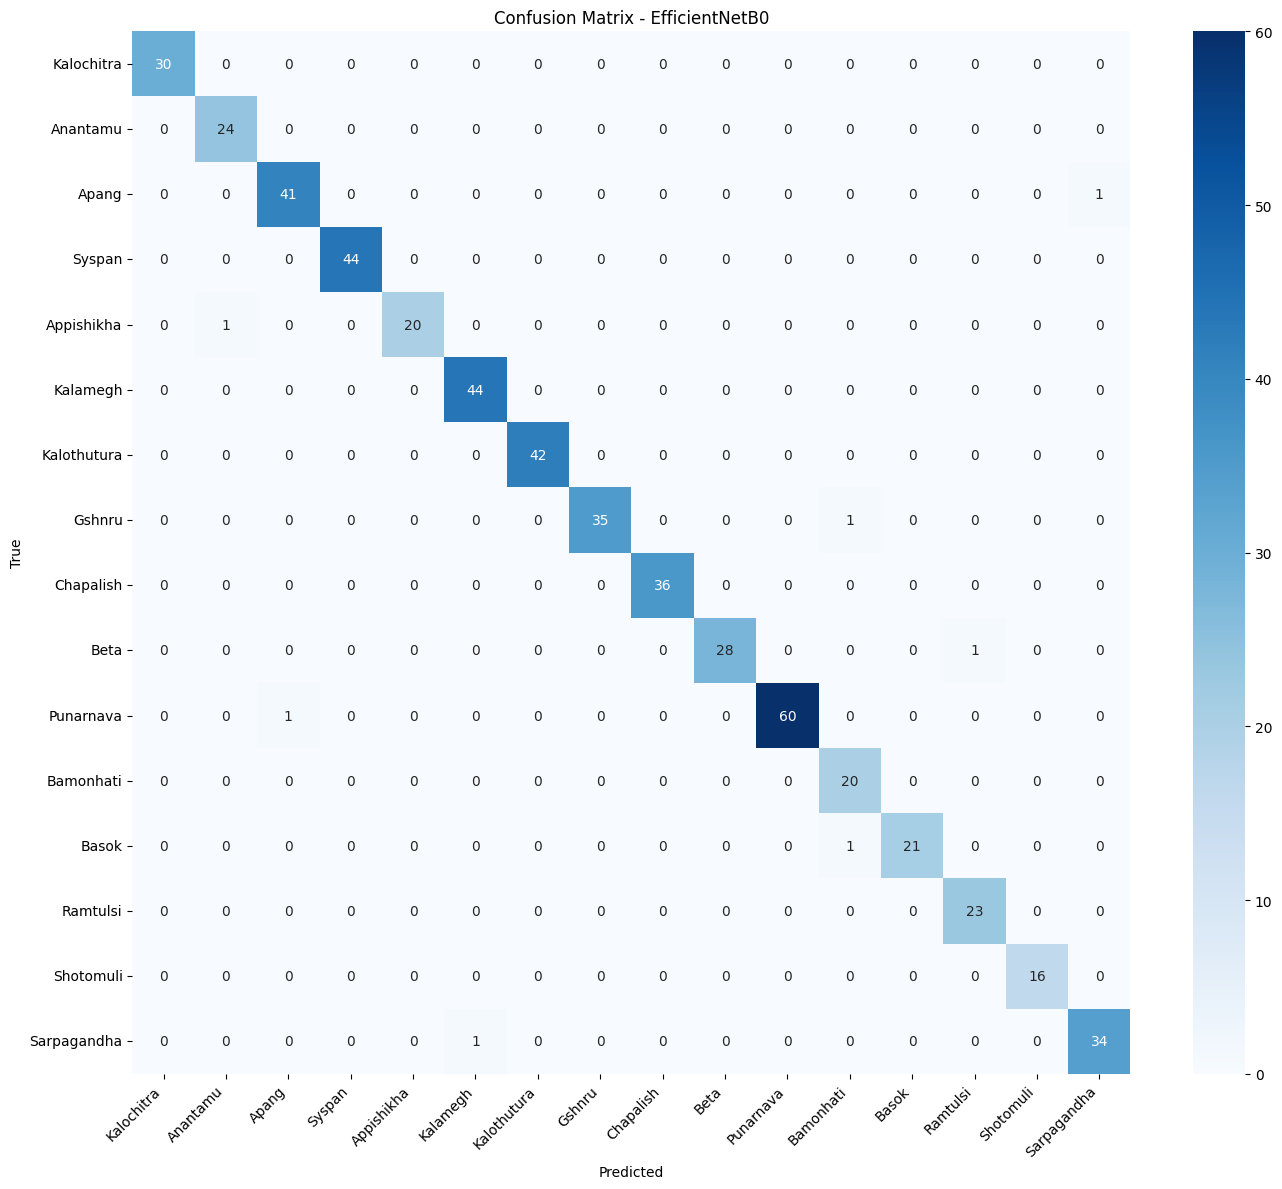

In [23]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - EfficientNetB0')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Macro-average AUC: 0.9999


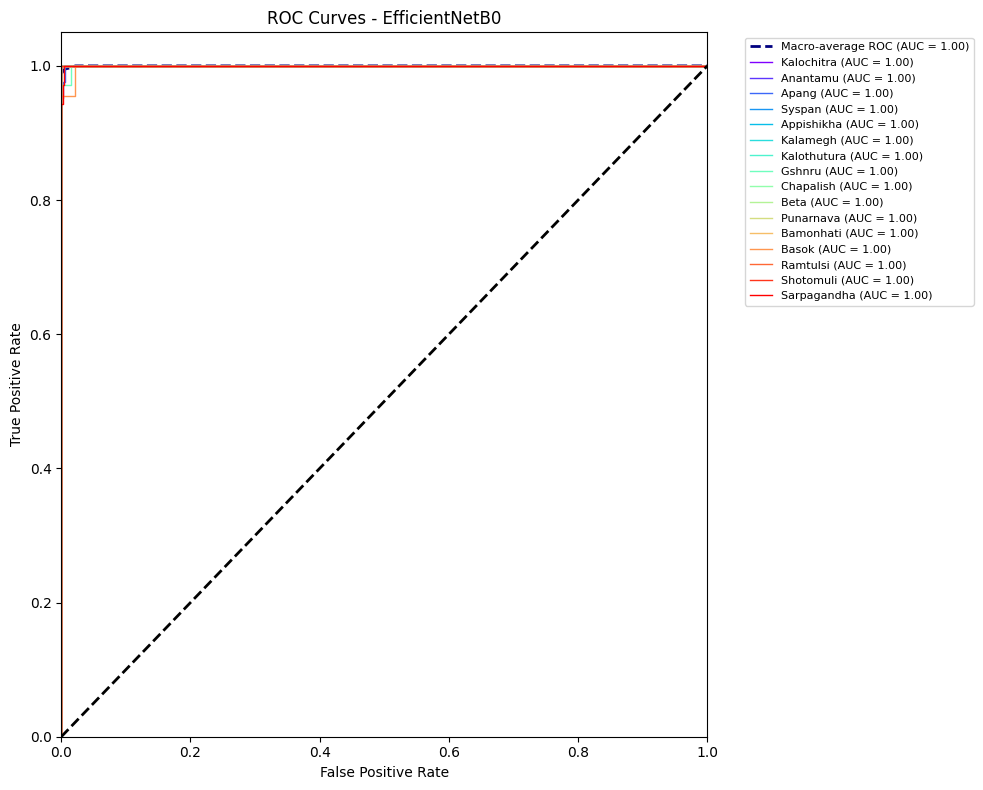

In [24]:
# Binarize labels for multi-class ROC
test_labels_bin = label_binarize(test_labels, classes=range(num_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f'\nMacro-average AUC: {roc_auc["macro"]:.4f}')

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle='--', linewidth=2)

# Plot individual class ROC curves
colors = plt.cm.rainbow(np.linspace(0, 1, num_classes))
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - EfficientNetB0')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [26]:
# Full classification report
print('\n=== Classification Report ===')
print(classification_report(test_labels, test_preds, target_names=class_names))


=== Classification Report ===
              precision    recall  f1-score   support

  Kalochitra       1.00      1.00      1.00        30
    Anantamu       0.96      1.00      0.98        24
       Apang       0.98      0.98      0.98        42
      Syspan       1.00      1.00      1.00        44
  Appishikha       1.00      0.95      0.98        21
    Kalamegh       0.98      1.00      0.99        44
 Kalothutura       1.00      1.00      1.00        42
      Gshnru       1.00      0.97      0.99        36
   Chapalish       1.00      1.00      1.00        36
        Beta       1.00      0.97      0.98        29
   Punarnava       1.00      0.98      0.99        61
   Bamonhati       0.91      1.00      0.95        20
       Basok       1.00      0.95      0.98        22
    Ramtulsi       0.96      1.00      0.98        23
   Shotomuli       1.00      1.00      1.00        16
 Sarpagandha       0.97      0.97      0.97        35

    accuracy                           0.99      

In [27]:
#summary table
summary_df = pd.DataFrame({
    'Model': ['EfficientNetB0'],
    'Pretrained': [USE_PRETRAINED],
    'Test Accuracy': [test_acc],
    'Precision': [test_precision],
    'Recall': [test_recall],
    'F1-Score': [test_f1],
    'AUC (Macro)': [roc_auc["macro"]],
    'Training Time (min)': [training_time/60],
    'Test Time (sec)': [test_time]
})

print('\n=== Model Summary ===')
print(summary_df.to_string(index=False))


=== Model Summary ===
         Model  Pretrained  Test Accuracy  Precision   Recall  F1-Score  AUC (Macro)  Training Time (min)  Test Time (sec)
EfficientNetB0       False       0.986667   0.987211 0.986667  0.986724     0.999913            12.542337         2.129071


In [29]:
# Save the trained model
torch.save(model.state_dict(), 'efficientnetb0_best_model.pth')
print('\nModel saved as efficientnetb0_best_model.pth')


Model saved as efficientnetb0_best_model.pth
